In [1]:
# ==============================================================
# TESTE 2 — ISOTROPIA OBSERVADA (CORRETO)
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr
import os

In [ ]:
# ==============================================================
# 1. LOAD DOS DADOS
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"

NORTH_PATHS = [os.path.join(BASE_PATH, f"SkyPosition_North{i}.csv") for i in range(1, 16)]
SOUTH_PATH = os.path.join(BASE_PATH, "SkyPosition_South.csv")

def load_catalog(path):
    df = pd.read_csv(path)
    return df[["RA", "DEC"]].dropna().reset_index(drop=True)

df_south = load_catalog(SOUTH_PATH)

In [3]:
# ==============================================================
# 2. GERADOR ISOTRÓPICO
# ==============================================================

def generate_catalog(n_sources, seed=None):
    rng = np.random.default_rng(seed)
    ra  = 360.0 * rng.random(n_sources)
    dec = np.degrees(np.arcsin(2.0 * rng.random(n_sources) - 1.0))
    return pd.DataFrame({"RA": ra, "DEC": dec})

# ==============================================================
# 3. CORTE OBSERVACIONAL (DEC)
# ==============================================================

def apply_dec_cut(df, dec_min, dec_max):
    return df[
        (df["DEC"] >= dec_min) &
        (df["DEC"] <= dec_max)
    ].reset_index(drop=True)

In [4]:
# ==============================================================
# 4. 2pACF
# ==============================================================

def get_2pacf(df_data, df_rand, nbins=20):

    cat = treecorr.Catalog(ra=df_data["RA"], dec=df_data["DEC"],
                           ra_units="deg", dec_units="deg")

    rnd = treecorr.Catalog(ra=df_rand["RA"], dec=df_rand["DEC"],
                           ra_units="deg", dec_units="deg")

    config = dict(min_sep=0.1, max_sep=180, nbins=nbins, sep_units="deg")

    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)

    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)

    nn.calculateXi(rr=rr, dr=dr)

    theta = np.exp(nn.meanlogr)
    return theta, nn.xi

# ==============================================================
# 5. DEFINIR JANELA OBSERVACIONAL
# ==============================================================

# juntar tudo para obter limites reais
all_data = []

for path in NORTH_PATHS:
    df_north = load_catalog(path)
    df_tmp = pd.concat([df_north, df_south])
    all_data.append(df_tmp)

all_data = pd.concat(all_data)

DEC_MIN = all_data["DEC"].min()
DEC_MAX = all_data["DEC"].max()

print(f"Janela observacional: [{DEC_MIN:.2f}, {DEC_MAX:.2f}]")

# ==============================================================
# 6. LOOP DOS DADOS
# ==============================================================

all_w = []

print("Processando dados reais...")

for i, path in enumerate(NORTH_PATHS):

    df_north = load_catalog(path)
    df_data  = pd.concat([df_north, df_south], ignore_index=True)

    # random com mesma janela
    df_rand = generate_catalog(len(df_data) * 20, seed=1000+i)
    df_rand = apply_dec_cut(df_rand, DEC_MIN, DEC_MAX)

    theta, w = get_2pacf(df_data, df_rand)
    all_w.append(w)

all_w = np.array(all_w)

mean_data = np.mean(all_w, axis=0)

# ==============================================================
# 7. H0 — ISOTROPIA OBSERVADA
# ==============================================================

print("Gerando H0 com janela...")

w_h0 = []

n_sources = len(df_data)

for i in tqdm(range(100)):

    d_iso = generate_catalog(n_sources, seed=i)
    d_iso = apply_dec_cut(d_iso, DEC_MIN, DEC_MAX)

    r_iso = generate_catalog(n_sources * 20, seed=i+1000)
    r_iso = apply_dec_cut(r_iso, DEC_MIN, DEC_MAX)

    _, w = get_2pacf(d_iso, r_iso)
    w_h0.append(w)

w_h0 = np.array(w_h0)

mean_h0 = np.mean(w_h0, axis=0)
std_h0  = np.std(w_h0, axis=0)

Janela observacional: [-85.20, 89.73]
Processando dados reais...
Gerando H0 com janela...


  0%|          | 0/100 [00:00<?, ?it/s]

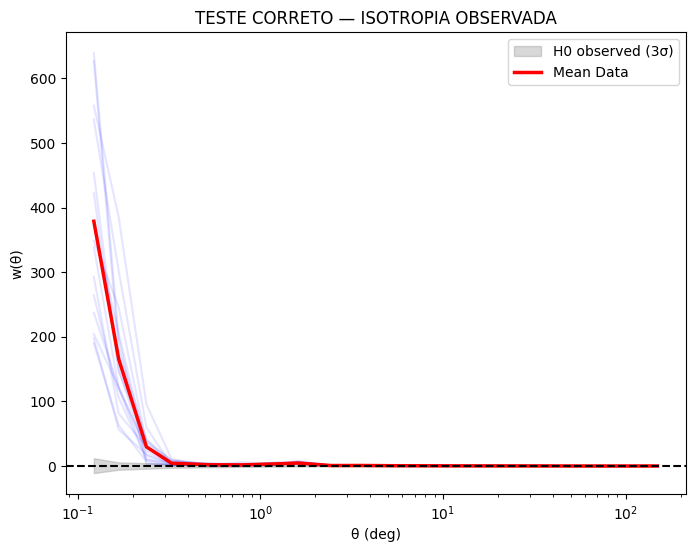

In [5]:
# ==============================================================
# 8. PLOT
# ==============================================================

plt.figure(figsize=(8,6))

plt.fill_between(theta,
                 mean_h0 - 3*std_h0,
                 mean_h0 + 3*std_h0,
                 color='gray', alpha=0.3,
                 label='H0 observed (3σ)')

for w in all_w:
    plt.plot(theta, w, color='blue', alpha=0.1)

plt.plot(theta, mean_data, 'r-', lw=2.5, label='Mean Data')

plt.xscale('log')
plt.axhline(0, ls='--', color='black')

plt.xlabel("θ (deg)")
plt.ylabel("w(θ)")
plt.title("TESTE CORRETO — ISOTROPIA OBSERVADA")
plt.legend()

plt.show()